In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, ndimage


def xcorr(X, Y):
    X -= X.mean()
    Y -= Y.mean()
    return X @ Y / (X.std() * Y.std()) / X.size


rng = np.random.default_rng(seed=0)

**correlations and sample size**

$\rho = 0: \quad \mathbb{V}[\hat\rho] \approx 1 / N$

In [2]:
n_repeats = 3000
sizes = [10, 15, 20, 50, 100]

sims = {size: np.zeros(n_repeats) for size in sizes}

for size in sizes:
    for repeat in range(n_repeats):
        XY = rng.multivariate_normal([0, 0], cov=[[1, 0], [0, 1]], size=size)
        sims[size][repeat] = xcorr(XY[:, 0], XY[:, 1])

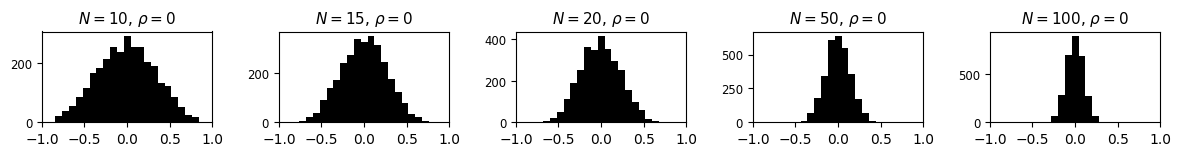

In [3]:
fig, axs = plt.subplots(ncols=len(sizes), figsize=(12, 1.5))
fig.tight_layout()
bins = np.arange(-1, 1 + 0.08, 0.08)
for idx, size in enumerate(sizes):
    axs[idx].hist(sims[size], bins=bins, color="k")
    axs[idx].set_title(r"$N = $" + str(size) + r", $\rho = 0$", fontsize=11)
    axs[idx].set_xlim([-1, 1])
    axs[idx].tick_params(axis="y", labelsize="small")

**cross correlations and autocorrelation**

In [4]:
ar1s = np.array([0, 0.2, 0.5, 0.7, 0.9])
fwhms = np.array([0.1, 1, 2, 4, 8])


sims_ar1 = {ar1: np.zeros(n_repeats) for ar1 in ar1s}
sims_fwhm = {fwhm: np.zeros(n_repeats) for fwhm in fwhms}

for idx in range(5):
    std = fwhms[idx] / (2 * np.sqrt(2 * np.log(2)))
    for repeat in range(n_repeats):
        Zs = rng.multivariate_normal([0, 0], cov=[[1, 0], [0, 1]], size=100)
        X_ar = signal.lfilter([1], np.r_[1, -ar1s[idx]], Zs[:, 0])
        Y_ar = signal.lfilter([1], np.r_[1, -ar1s[idx]], Zs[:, 1])
        X_g = ndimage.gaussian_filter1d(Zs[:, 0], sigma=std)
        Y_g = ndimage.gaussian_filter1d(Zs[:, 1], sigma=std)
        sims_ar1[ar1s[idx]][repeat] = xcorr(X_ar, Y_ar)
        sims_fwhm[fwhms[idx]][repeat] = xcorr(X_g, Y_g)

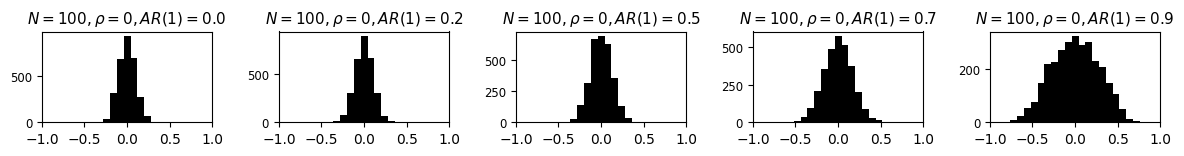

In [5]:
fig, axs = plt.subplots(ncols=len(ar1s), figsize=(12, 1.5))
fig.tight_layout()
bins = np.arange(-1, 1 + 0.08, 0.08)
for idx, ar1 in enumerate(ar1s):
    axs[idx].hist(sims_ar1[ar1], bins=bins, color="k")
    axs[idx].set_title(r"$N = 100, \rho=0, AR(1) = $" + str(ar1), fontsize=11)
    axs[idx].set_xlim([-1, 1])
    axs[idx].tick_params(axis="y", labelsize="small")

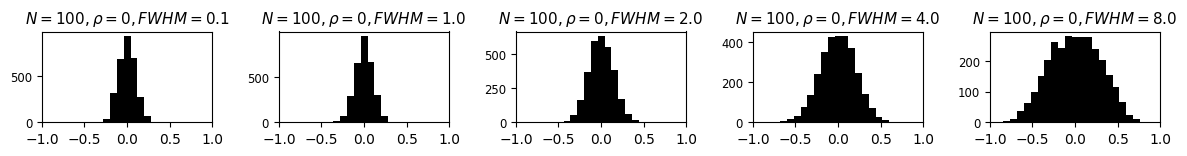

In [6]:
fig, axs = plt.subplots(ncols=len(ar1s), figsize=(12, 1.5))
fig.tight_layout()
bins = np.arange(-1, 1 + 0.08, 0.08)
for idx, fwhm in enumerate(fwhms):
    axs[idx].hist(sims_fwhm[fwhm], bins=bins, color="k")
    axs[idx].set_title(r"$N = 100, \rho=0, FWHM = $" + str(fwhm), fontsize=11)
    axs[idx].set_xlim([-1, 1])
    axs[idx].tick_params(axis="y", labelsize="small")